# Acoustic Scattering for 3D

This notebook contains code to validate our model for the 2D problem of scattering field estimation through a circular scatterer.

Code provided here can be easily adapted for general shape given a groundtruth result to compare to.

Note : The pre-trained model PHISK for 3D has been badly optimized (one of the LoRA training has not been finished) and the value of T chosen here may be refined.
Due to timing issues, we still give this model as example.

## Google Colab setup

In [1]:
# Export the modules
!git clone https://github.com/Dankradino/Acoustic-Scattering-PINN.git

import os
os.getcwd()
os.chdir('/content/Acoustic-Scattering-PINN/')
os.getcwd()

Cloning into 'Acoustic-Scattering-PINN'...
remote: Enumerating objects: 554, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 554 (delta 34), reused 46 (delta 21), pack-reused 488 (from 1)
Receiving objects: 100% (554/554), 689.10 MiB | 26.60 MiB/s, done.
Resolving deltas: 100% (244/244), done.
Updating files: 100% (145/145), done.


'/content/Acoustic-Scattering-PINN'

In [2]:
!pip install trimesh pysofaconventions==0.1.5 rtree  # Sufficient for testing models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.6/736.6 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 80.4 MB/s eta 0:00:00


## Import and configuration setup

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from model import init_model_from_conf, load_directional_model, init_conditioned_model, load_interpolated_model
from shape import generate_circle
from eval import evaluate_circle_estimation, evaluate_circle_estimation_direction, sound_hard_circle
import yaml
from utils import load_config, generate_grid
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon


from shape import  generate_sphere, get_sphere_param
from Trainer import Trainer3D
from utils import create_3d_mesh_mask
import trimesh
from eval import evaluate_sphere_estimation


torch.manual_seed(30)

In [4]:
#Load file
model_name = 'rff'                                       # Name of model used
dim = '3D'
config_filename = f'config/{dim}/scattering/config_{model_name}.yaml'
hconfig_filename = f'config/{dim}/scattering/hconfig.yaml'
ref_filename = f'checkpoints/{dim}/reference/{model_name}.pth'  #Filename of the reference model
phisk_filename = f'checkpoints/{dim}/phisk/{model_name}.pth'
lora_dir = f'checkpoints/{dim}/lora/'  #Directory containin lora_weight
loss_fn = nn.MSELoss()

config, DTYPE = load_config(config_filename)
device = config['device']
config['model'] = model_name


# Note we provide another model trained for direction [1.,0.,0.] that you can test by just replacing
# ref_filename = f'checkpoints/{dim}/scattering/{model_name}.pth'
# and config['direction'] = torch.tensor([[1.], [0.], [0.]], device='cuda:0')


with open(hconfig_filename) as file:
    hconfig = yaml.safe_load(file)

## Reference model evaluation

In [5]:
# Loading and evaluating reference model

reference_model = init_model_from_conf(config).to(device)
print('Loading weights for reference model')
reference_model.load_state_dict(torch.load(ref_filename))
print('Reference model loaded!')


#Can be adapted with a custom shape, here we defined a spherical scatterer
config['custom_shape'] = False
mesh_path = generate_sphere(radius=config['mesh_param']['r'], subdivisions=8, center = config['mesh_param']['center'])
mesh =  trimesh.load(mesh_path)
boundary , normals = get_sphere_param(mesh.vertices)

# Defining the trainer (initialize the solution to the problem)
config['res'] = 10     # For Google Colab, baseline for paper is 128, 10 gives 10^3 - points inside the sphere evaluation points

dataloader = {'normals' : normals,
        'boundary' : boundary,
        'polygon' : mesh.vertices,
        'mesh_mask': create_3d_mesh_mask(config, mesh),
        'R' : config['mesh_param']['r'],
            }

trainer = Trainer3D(reference_model, dataloader, loss_fn, config)

# Evaluation of the reference model
evaluate_sphere_estimation(reference_model, trainer, config, config['mesh_param']['r'])

Loading weights for reference model
Reference model loaded!
Created trimesh sphere: trimesh_sphere.obj
  Center: [0.0, 0.0, 0.0]
  Radius: 0.2
  Subdivisions: 8
  Vertices: 655362
  Faces: 1310720
  Watertight: True
  Volume: 0.033510
Incoming wave mode : plane
Incident direction: [0.5773503 0.5773503 0.5773503]
Generating 3D grid: L=0.5, res=10
Grid shape: torch.Size([1000, 3])
Grid range: x∈[-0.50, 0.50]
Calculating incident field...
Calculating scattered field...
Field calculated! Shape: torch.Size([1000])
Field range: 0.000 to 1.337
MSE: 4.0363e-07
Variance: 5.4149e-02
R2 Score : 1.00e+00
L2 Score : tensor(0.0027, device='cuda:0', dtype=torch.float64)
NMSE complex : -5.1283e+01
NMSE Real: -51.3768, NMSE Imag: -51.1860
Cosine Similarity Real: 2.4467323551657927e-06, Cosine Similarity Imag: 2.91751330860901e-06


## Loading different models for comparison with PHISK

In [6]:
# Load LoRA Interpolation for comparison with PHISK
lora_interpolation = load_interpolated_model(reference_model, lora_dir, config)

Loading LoRA ensemble from checkpoints/3D/lora/
Found 6 LoRA weight files
Loading +0.0+0.0+1.0.pth
Debug: LoRA state structure:
net.0: dict with 3 keys
  lora_A: tensor torch.Size([12, 1024])
  lora_B: tensor torch.Size([512, 12])
  alpha: <class 'float'> = 1.0
net.2: dict with 3 keys
  lora_A: tensor torch.Size([12, 512])
  lora_B: tensor torch.Size([512, 12])
  alpha: <class 'float'> = 1.0
net.4: dict with 3 keys
  lora_A: tensor torch.Size([12, 512])
  lora_B: tensor torch.Size([512, 12])
  alpha: <class 'float'> = 1.0
net.6: dict with 3 keys
  lora_A: tensor torch.Size([12, 512])
  lora_B: tensor torch.Size([2, 12])
  alpha: <class 'float'> = 1.0
  Direction: [0. 0. 1.]
Loading +0.0-1.0+0.0.pth
  Direction: [ 0. -1.  0.]
Loading +0.0+0.0-1.0.pth
  Direction: [ 0.  0. -1.]
Loading +0.0+1.0+0.0.pth
  Direction: [0. 1. 0.]
Loading -1.0+0.0+0.0.pth
  Direction: [-1.  0.  0.]
Loading +1.0+0.0+0.0.pth
  Direction: [1. 0. 0.]
Debug: Parameter shapes found:
  net.0.lora_A: torch.Size([12, 

In [7]:
# Loading PHISK
config['lora_train'] = False

hconfig['T'] = 0.5
print(f'Loading PHISK')
phisk_model = load_directional_model(
reference_network=reference_model,
checkpoint_path=phisk_filename,
config=config,
hconfig=hconfig
)

print(f'Done!')

Loading PHISK
Incoming wave mode : plane
Incident direction: [0.5773503 0.5773503 0.5773503]
Generating 3D grid: L=0.5, res=10
Grid shape: torch.Size([1000, 3])
Grid range: x∈[-0.50, 0.50]
Calculating incident field...
Calculating scattered field...
Field calculated! Shape: torch.Size([1000])
Field range: 0.000 to 1.337
Loading hypernetwork checkpoint from checkpoints/3D/phisk/rff.pth
dict_keys(['attention_state', 'hypernetwork_state', 'fourier_features_B', 'lora_directions', 'param_shapes', 'lora_states', 'interpolation_state'])
Successfully loaded hypernetwork with:
  - 6 LoRA directions
  - 49176 total parameters
  - Attention mechanism and hypernetwork states restored
Done!


## Visualization of the reference field and comparison to groundtruth

In [8]:
def plot_field(u, res, grid, L = config['L']):
    """
    Plot a pressure field u in x,y and z direction for x = axis_choice
    """
    axis_choice = res//2
    R = config['mesh_param']['r']
    # Mask (here we use groundtruth formula for Colab to still have decent visualization)
    mesh_mask = (grid[:, 0]**2 + grid[:, 1]**2 + grid[:, 2]**2) < R**2
    mesh_mask = mesh_mask.reshape(res, res, res)
    u_real = u[:, 0]
    u_real = u_real.reshape(res, res, res)
    u_imag = u[:, 1]
    u_imag = u_imag.reshape(res, res, res)
    u_rez = u_real[:, :, axis_choice]
    u_imz = u_imag[:, :, axis_choice]
    u_rey = u_real[: , axis_choice ,:]
    u_imy = u_imag[: , axis_choice ,:]
    u_rex = u_real[axis_choice , :, :]
    u_imx = u_imag[axis_choice , :, :]

    # Apply masks to hide mesh regions
    xy_mask = mesh_mask[:, :, axis_choice]
    xz_mask = mesh_mask[:, axis_choice, :]
    yz_mask = mesh_mask[axis_choice, :, :]

    u_rez = np.ma.masked_where(xy_mask, u_rez)
    u_imz = np.ma.masked_where(xy_mask, u_imz)
    u_rex = np.ma.masked_where(yz_mask, u_rex)
    u_imx = np.ma.masked_where(yz_mask, u_imx)
    u_rey = np.ma.masked_where(xz_mask, u_rey)
    u_imy = np.ma.masked_where(xz_mask, u_imy)

    fig, axs = plt.subplots(3, 2, figsize=(12, 5))
    # Real part plot
    im0 = axs[0, 0].imshow(u_rez, extent=[-L, L, -L, L], origin='lower', cmap='viridis')
    axs[0, 0].set_title('XY Real part')
    fig.colorbar(im0, ax=axs[0, 0])

    # Imaginary part plot
    im1 = axs[0,1].imshow(u_imz, extent=[-L, L, -L, L], origin='lower', cmap='viridis')
    axs[0,1].set_title('XY Imag part')
    fig.colorbar(im1, ax=axs[0, 1])

    # Real part plot
    im2 = axs[1, 0].imshow(u_rey , extent=[-L, L, -L, L], origin='lower', cmap='viridis')
    axs[1, 0].set_title('XZ Real part')
    fig.colorbar(im2, ax=axs[1, 0])

    # Imaginary part plot
    im3 = axs[1,1].imshow(u_imy , extent=[-L, L, -L, L], origin='lower', cmap='viridis')
    axs[1,1].set_title('XZ Imag part')
    fig.colorbar(im3, ax=axs[1, 1])
    plt.tight_layout()

    # Real part plot
    im4 = axs[2, 0].imshow(u_rex , extent=[-L, L, -L, L], origin='lower', cmap='viridis')
    axs[2, 0].set_title('YZ Real part')
    fig.colorbar(im4, ax=axs[2, 0])

    # Imaginary part plot
    im5 = axs[2,1].imshow(u_imx , extent=[-L, L, -L, L], origin='lower', cmap='viridis')
    axs[2,1].set_title('YZ Imag part')
    fig.colorbar(im5, ax=axs[2, 1])
    plt.tight_layout()
    plt.show()


### Estimated scattered pressure field by the reference network

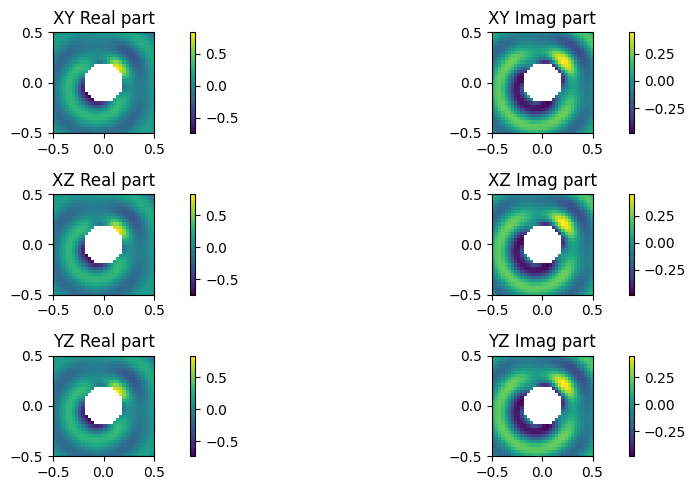

In [9]:
res = 32
grid = generate_grid(config['L'], res, 3, device = config['device'])
p_s_estimated = reference_model(grid).detach().cpu().numpy()
plot_field(p_s_estimated, res, grid.cpu().numpy())


### Groundtruth scattered pressure field

Incident direction: [0.5773503 0.5773503 0.5773503]
Generating 3D grid: L=0.5, res=32
Grid shape: torch.Size([32768, 3])
Grid range: x∈[-0.50, 0.50]
Calculating incident field...
Calculating scattered field...
Field calculated! Shape: torch.Size([32768])
Field range: 0.000 to 1.744


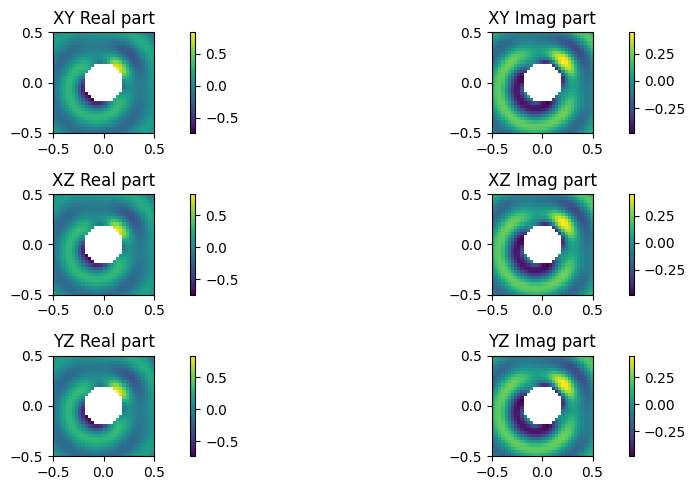

In [10]:
from eval import AcousticScattering3D

# Take some time
R = config['mesh_param']['r']
k = 2 * np.pi * config['frequency'] / config['celerity']
scatterer = AcousticScattering3D(
sphere_radius = R,
incident_direction = config['direction'].cpu().numpy(),
device = config['device']
)
p_s_true, _ = scatterer.total_field_pytorch(config['L'], res, k * R)
p_s_true = torch.stack((p_s_true.real, p_s_true.imag) , dim = 1).cpu().numpy()
plot_field(p_s_true, res, grid.cpu().numpy())

### Difference of scattered pressure fields (reference network estimate)

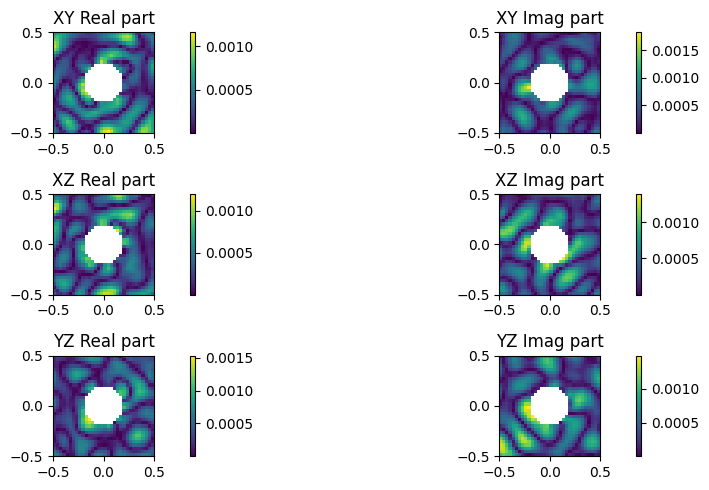

In [11]:
p_s_diff = np.abs(p_s_true - p_s_estimated)
plot_field(p_s_diff, res, grid.cpu().numpy())

## Phisk validation

In [12]:
example_direction = torch.tensor([-1., 0., 0.], device=device)
another_direction = torch.tensor([0., -1., 1.], device=device)

### LoRA Interpolation visualization

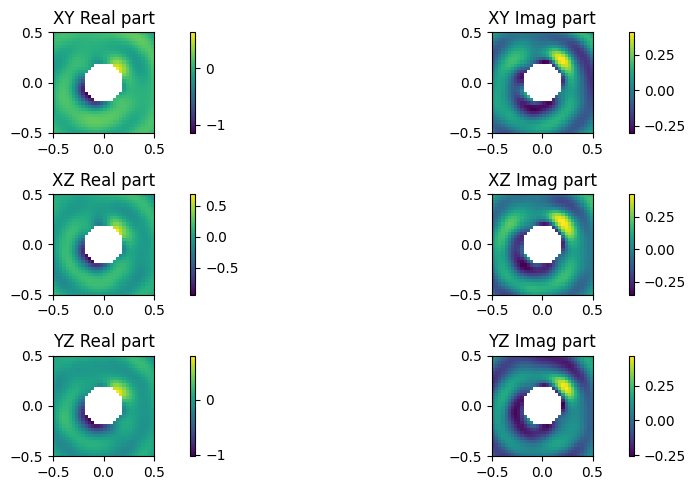

In [13]:
p_s_estimated = lora_interpolation(grid, direction = config['direction'].T[0]).detach().cpu().numpy()
plot_field(p_s_estimated, res, grid.cpu().numpy())

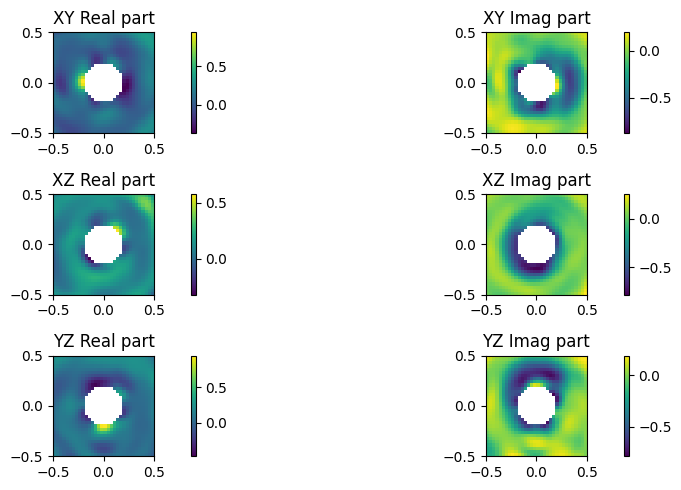

In [14]:
p_s_estimated = lora_interpolation(grid, direction = example_direction.T).detach().cpu().numpy()
plot_field(p_s_estimated, res, grid.cpu().numpy())

### Phisk estimation visualization

In [15]:
print(phisk_model.trainer.T)

0.5


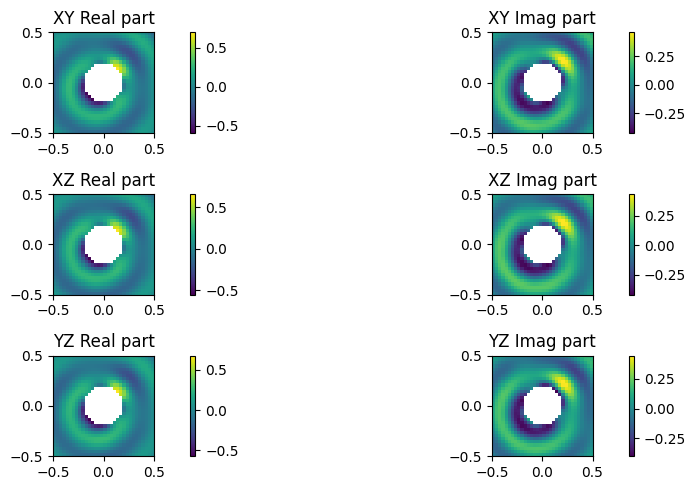

In [16]:
# On reference direction
p_s_estimated = phisk_model(grid, direction = config['direction'].T[0]).detach().cpu().numpy()
plot_field(p_s_estimated, res, grid.cpu().numpy())

# Shape are good however extreme values are badly captured.

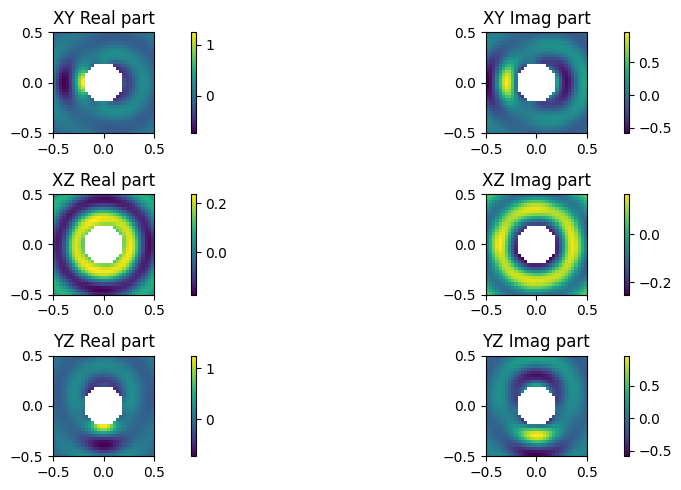

In [17]:
# Example direction

p_s_estimated = phisk_model(grid, direction = example_direction.T).detach().cpu().numpy()
plot_field(p_s_estimated, res, grid.cpu().numpy())


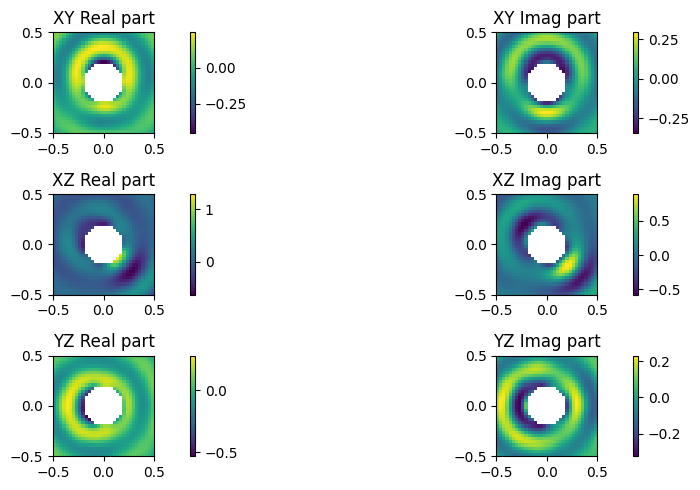

In [18]:
# Example of random direction

p_s_estimated = phisk_model(grid, direction = another_direction.T).detach().cpu().numpy()
plot_field(p_s_estimated, res, grid.cpu().numpy())

# Scattered shape are distinguishible inside produced fields

## Numerical evaluation of PHISK

### On a circle around the sphere


In [23]:
from eval import R2_L2, nmse, cosine_similarity

def evaluate_sphere_estimation(model, trainer, config, display = False):
    L = config['L']
    x_grid = trainer.x_grid
    target = torch.tensor(trainer.solution, device = trainer.device)
    mask = x_grid[:,0]**2 + x_grid[:,1]**2 + x_grid[:, 2]**2> config['mesh_param']['r']**2
    res = config['res']
    with torch.no_grad():
        model.eval()
        prediction = torch.zeros((x_grid.shape[0],2), device = config['device'])
        print(config['direction'])
        prediction[mask,:] = model(x_grid[mask,:], direction = config['direction'].T[0])
    #R2_L2(prediction, target)
    nmse_real = nmse(prediction[:,0], target[:,0])
    nmse_imag = nmse(prediction[:,1], target[:,1])

    cos_sim_real = cosine_similarity(prediction[:,0], target[:,0])
    cos_sim_imag = cosine_similarity(prediction[:,1], target[:,1])

    real_error = prediction[:, 0] - target[:, 0]
    imag_error = prediction[:, 1] - target[:, 1]
    # Compute per-sample NMSE values
    nmse_real_vals = (real_error ** 2) / (target[:, 0] ** 2 + 1e-8)
    nmse_imag_vals = (imag_error ** 2) / (target[:, 1] ** 2 + 1e-8)

    # Convert to dB first, then compute mean/std
    nmse_real_dB_vals = 10 * torch.log10(nmse_real_vals + 1e-12)
    nmse_imag_dB_vals = 10 * torch.log10(nmse_imag_vals + 1e-12)

    nmse_real_std = nmse_real_dB_vals.std()
    nmse_imag_std = nmse_imag_dB_vals.std()

    print(f"NMSE Real: {nmse_real.item():.4f}, "
        f"NMSE Imag: {nmse_imag.item():.4f}")
    print(f"Cosine Similarity Real: {cos_sim_real.item()}, Cosine Similarity Imag: {cos_sim_imag.item()}")
    return (nmse_real.item() + nmse_imag.item())/2

N_dir = 96

# Base direction
base_dir = torch.tensor([1., 1., 1.], device=device)
base_dir = base_dir / torch.linalg.norm(base_dir)

# Choose a reference axis not parallel to base_dir (to build a local frame)
ref = torch.tensor([0., -1., 1.], device=device)
if torch.allclose(base_dir, ref):
    ref = torch.tensor([0., 1., 0.], device=device)

# Build orthonormal basis around base_dir
u = torch.cross(base_dir, ref)
u = u / torch.linalg.norm(u)
v = torch.cross(base_dir, u)
v = v / torch.linalg.norm(v)


radius = 0.2

# Generate directions on the circle
angles = torch.linspace(0, 2 * torch.pi, N_dir, device=device)
dirs = []
for angle in angles:
    d = base_dir + radius * (torch.cos(angle) * u + torch.sin(angle) * v)
    d = d / torch.linalg.norm(d)
    dirs.append(d)
Error_model_avg = 0
Error_lora_avg = 0
# Stack into one tensor (shape [3, N_dir])
directions = torch.stack(dirs, dim=1)
directions = directions.T
res = 8
k = 2 * np.pi * config['frequency'] / config['celerity']
for direction in directions:
  direction = direction.unsqueeze(1)
  direction = direction / torch.linalg.norm(direction)
  config['direction'] = direction
  scatterer = AcousticScattering3D(
  sphere_radius = dataloader['R'],
  incident_direction = direction.cpu().numpy(),
  device = device,
  verbose = False,
  )
  solution, x_grid = scatterer.total_field_pytorch(config['L'], res, k * dataloader['R'])
  x_grid = x_grid.to(device)
  solution = solution.to(device)
  solution = torch.stack((solution.real, solution.imag) , dim = 1)
  trainer.solution = solution
  trainer.x_grid = x_grid
  Error_model = evaluate_sphere_estimation(phisk_model, trainer, config)
  Error_lora = evaluate_sphere_estimation(lora_interpolation, trainer, config)
  print(f'Error model, {Error_model}', 'dB')
  print(f'Error lora, {Error_lora}', 'dB')
  Error_model_avg += Error_model
  Error_lora_avg += Error_lora


Error_model_avg /= N_dir
Error_lora_avg /= N_dir
print('\n')
print(f'Error model avg, {Error_model_avg}', 'dB')
print(f'Error lora avg, {Error_lora_avg}', 'dB')

tensor([[0.7263],
        [0.4861],
        [0.4861]], device='cuda:0')
NMSE Real: -11.6392, NMSE Imag: -12.5605
Cosine Similarity Real: 0.013063948715028695, Cosine Similarity Imag: 0.018168833418103048
tensor([[0.7263],
        [0.4861],
        [0.4861]], device='cuda:0')
NMSE Real: -3.2219, NMSE Imag: -5.8143
Cosine Similarity Real: 0.2645139047025642, Cosine Similarity Imag: 0.13425909468341657
Error model, -12.099845983684142 dB
Error lora, -4.518143953639495 dB
tensor([[0.7259],
        [0.4954],
        [0.4771]], device='cuda:0')
NMSE Real: -11.6036, NMSE Imag: -12.5407
Cosine Similarity Real: 0.013051729707930226, Cosine Similarity Imag: 0.018248648565474146
tensor([[0.7259],
        [0.4954],
        [0.4771]], device='cuda:0')
NMSE Real: -3.1746, NMSE Imag: -5.7689
Cosine Similarity Real: 0.2671829295364584, Cosine Similarity Imag: 0.13616684813036695
Error model, -12.072136971212704 dB
Error lora, -4.4717631821163515 dB
tensor([[0.7249],
        [0.5051],
        [0.4685]]

### On random directions

In [25]:
dirs = []
for _ in range(N_dir):
    d = 2 * torch.rand(3)-1
    d = d / torch.linalg.norm(d)
    dirs.append(d)
Error_model_avg = 0
Error_lora_avg = 0
# Stack into one tensor (shape [3, N_dir])
directions = torch.stack(dirs, dim=1)
directions = directions.T
res = 8
k = 2 * np.pi * config['frequency'] / config['celerity']
for direction in directions:
  direction = direction.unsqueeze(1)
  direction = direction / torch.linalg.norm(direction)
  config['direction'] = direction
  scatterer = AcousticScattering3D(
  sphere_radius = dataloader['R'],
  incident_direction = direction.cpu().numpy(),
  device = device,
  verbose = False,
  )
  solution, x_grid = scatterer.total_field_pytorch(config['L'], res, k * dataloader['R'])
  x_grid = x_grid.to(device)
  solution = solution.to(device)
  solution = torch.stack((solution.real, solution.imag) , dim = 1)
  trainer.solution = solution
  trainer.x_grid = x_grid
  Error_model = evaluate_sphere_estimation(phisk_model, trainer, config)
  Error_lora = evaluate_sphere_estimation(lora_interpolation, trainer, config)
  print(f'Error model, {Error_model}', 'dB')
  print(f'Error lora, {Error_lora}', 'dB')
  Error_model_avg += Error_model
  Error_lora_avg += Error_lora


Error_model_avg /= N_dir
Error_lora_avg /= N_dir

print('\n')
print(f'Error model avg, {Error_model_avg}', 'dB')
print(f'Error lora avg, {Error_lora_avg}', 'dB')

#As explained in the introduction for this pretrained model, results in negative coordinates direction could be clearly enhanced.

tensor([[0.4064],
        [0.5402],
        [0.7370]])
NMSE Real: -11.1515, NMSE Imag: -12.3269
Cosine Similarity Real: 0.015926570994315714, Cosine Similarity Imag: 0.019652724232605223
tensor([[0.4064],
        [0.5402],
        [0.7370]])
NMSE Real: -4.0585, NMSE Imag: -5.2089
Cosine Similarity Real: 0.22065839722024583, Cosine Similarity Imag: 0.1625832558463638
Error model, -11.739180820281412 dB
Error lora, -4.633675131996703 dB
tensor([[ 0.4721],
        [-0.8707],
        [-0.1381]])
NMSE Real: -9.6848, NMSE Imag: -9.8821
Cosine Similarity Real: 0.02336600950429113, Cosine Similarity Imag: 0.03813388213847846
tensor([[ 0.4721],
        [-0.8707],
        [-0.1381]])
NMSE Real: 1.5255, NMSE Imag: 1.3573
Cosine Similarity Real: 0.9366612984240679, Cosine Similarity Imag: 0.8936920988950926
Error model, -9.783434237630374 dB
Error lora, 1.4413630191780955 dB
tensor([[ 0.0749],
        [-0.7129],
        [-0.6973]])
NMSE Real: -9.1823, NMSE Imag: -9.8329
Cosine Similarity Real: 0.0

# Visualization of networks results compared to reference direction

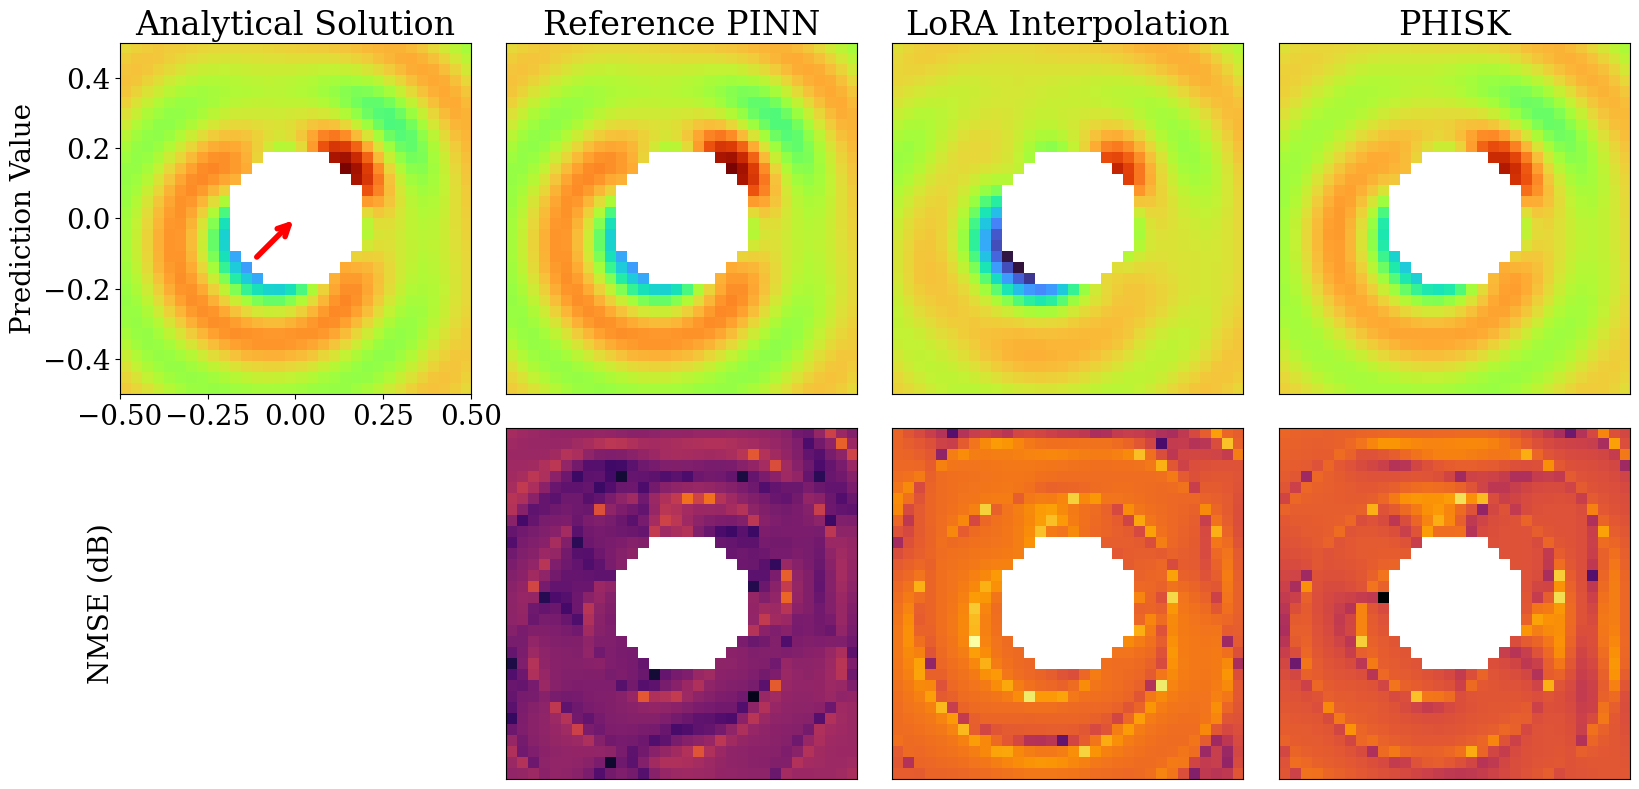

NMSE values: [-51.97610017284802, -4.806330247048031, -11.98810189815141]


In [32]:
# Visualize network results compared for a given direction

def compare_models_3d(models, model_names, target, grid, res, config,
                      slice_axis='z', slice_position=None, direction=None):
    """
    Compare multiple models on a 3D pressure field slice.

    Parameters:
    -----------
    models : list
        List of model objects (e.g., [reference_model, conditioned_model, lora_interp, phisk_model])
    model_names : list of str
        Names for each model (e.g., ['Reference PINN', 'Conditioned PINN', ...])
    target : torch.Tensor
        Ground truth solution (shape: [res^3, 2])
    grid : torch.Tensor
        3D grid points (shape: [res^3, 3])
    res : int
        Resolution parameter
    config : dict
        Configuration dictionary containing 'L', 'mesh_param', 'device'
    slice_axis : str
        Axis to slice ('x', 'y', or 'z'), default 'z'
    slice_position : int or None
        Position along axis to slice. If None, uses middle (res//2)
    direction : torch.Tensor or None
        Direction vector for conditional models
    """

    device = config['device']
    L = config['L']
    R = config['mesh_param']['r']

    if slice_position is None:
        slice_position = res // 2

    # Configure matplotlib
    plt.rcParams['text.usetex'] = False
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.size'] = 20
    plt.rcParams['axes.titlesize'] = 24
    plt.rcParams['axes.labelsize'] = 20

    # Create mask for the obstacle
    mesh_mask = (grid[:, 0]**2 + grid[:, 1]**2 + grid[:, 2]**2) < R**2
    mask = ~mesh_mask  # Points outside the obstacle

    # Generate predictions from all models
    predictions = []
    nmse_values = []

    with torch.no_grad():
        for model in models:
            model.eval()
            pred = torch.zeros((res**3, 2), device=device)

            # Call model based on whether it needs direction
            if direction is not None:
                try:
                    pred[mask, :] = model(grid[mask, :], direction=direction.T[0])
                except TypeError:
                    # Model
                    pred[mask, :] = model(grid[mask, :])
            else:
                pred[mask, :] = model(grid[mask, :])

            predictions.append(pred)

            # Calculate NMSE
            mse = torch.mean((pred[:, 0] - target[:, 0])**2)
            target_power = torch.mean(target[:, 0]**2)
            nmse = 10 * torch.log10(mse / target_power)
            nmse_values.append(nmse.item())

    # Extract slice based on axis
    def extract_slice(field_3d, axis, position):
        if axis == 'z':
            return field_3d[:, :, position]
        elif axis == 'y':
            return field_3d[:, position, :]
        elif axis == 'x':
            return field_3d[position, :, :]
        else:
            raise ValueError("axis must be 'x', 'y', or 'z'")

    # Prepare data for plotting
    n_models = len(models)

    # Reshape target and predictions
    target_np = target.cpu().numpy().reshape(res, res, res, 2)
    target_slice = extract_slice(target_np[:, :, :, 0], slice_axis, slice_position)

    predictions_np = [pred.cpu().numpy().reshape(res, res, res, 2)
                      for pred in predictions]
    pred_slices = [extract_slice(pred[:, :, :, 0], slice_axis, slice_position)
                   for pred in predictions_np]

    # Create mask for the slice
    mesh_mask_3d = mesh_mask.cpu().numpy().reshape(res, res, res)
    slice_mask = extract_slice(mesh_mask_3d, slice_axis, slice_position)

    # Calculate NMSE plots
    eps = 1e-12
    def calculate_nmse_plot(pred, target):
        mse = (pred - target) ** 2 + eps
        target_square = target**2 + eps
        return 10 * np.log10(mse / target_square)

    nmse_plots = [calculate_nmse_plot(pred_slice, target_slice)
                  for pred_slice in pred_slices]

    # Apply mask to hide obstacle regions
    target_slice = np.ma.masked_where(slice_mask, target_slice)
    pred_slices = [np.ma.masked_where(slice_mask, pred) for pred in pred_slices]
    nmse_plots = [np.ma.masked_where(slice_mask, nmse) for nmse in nmse_plots]

    # Calculate global min/max for consistent colormaps
    all_predictions = [target_slice] + pred_slices
    real_min = min([pred.min() for pred in all_predictions])
    real_max = max([pred.max() for pred in all_predictions])

    nmse_min = min([nmse.min() for nmse in nmse_plots])
    nmse_max = max([nmse.max() for nmse in nmse_plots])

    # Setup axis labels based on slice axis
    if slice_axis == 'z':
        xlabel, ylabel = 'X', 'Y'
    elif slice_axis == 'y':
        xlabel, ylabel = 'X', 'Z'
    else:  # x
        xlabel, ylabel = 'Y', 'Z'

    # Create plot
    fig, axs = plt.subplots(2, n_models + 1, figsize=(5 * (n_models + 1), 10),
                            constrained_layout=False)
    plt.subplots_adjust(right=0.88, hspace=0., wspace=0.1)

    # --- Top row: Raw predictions ---
    # Plot target
    im_top = axs[0, 0].imshow(target_slice, extent=[-L, L, -L, L],
                             origin='lower', cmap='turbo', vmin=real_min, vmax=real_max)
    axs[0, 0].set_title('Analytical Solution')
    axs[0, 0].set_xlabel(xlabel)
    axs[0, 0].set_ylabel(ylabel)

    # Add direction arrow if provided
    if direction is not None and slice_axis == 'z':
        center = np.array([0., 0.])
        axs[0, 0].annotate('', xy=(0., 0.),
                          xytext=(-R * direction[0][0].cpu().numpy(),
                                 -R * direction[1][0].cpu().numpy()),
                          arrowprops=dict(arrowstyle='->', color='red', lw=4))

    # Plot model predictions
    for i, (pred_slice, model_name, nmse_val) in enumerate(zip(pred_slices, model_names, nmse_values)):
        im_top = axs[0, i+1].imshow(pred_slice, extent=[-L, L, -L, L],
                                   origin='lower', cmap='turbo', vmin=real_min, vmax=real_max)
        axs[0, i+1].set_title(f'{model_name}')
        axs[0, i+1].set_xticks([])
        axs[0, i+1].set_yticks([])

    # --- Bottom row: NMSE error plots ---
    # Empty plot for target column
    axs[1, 0].imshow(np.full((res, res), np.nan), extent=[-L, L, -L, L],
                    origin='lower', cmap='inferno')
    for spine in axs[1, 0].spines.values():
        spine.set_visible(False)
    axs[1, 0].set_xticks([])
    axs[1, 0].set_yticks([])

    # Plot NMSE for models
    for i, (nmse_plot, model_name, nmse_val) in enumerate(zip(nmse_plots, model_names, nmse_values)):
        im_bottom = axs[1, i+1].imshow(nmse_plot, extent=[-L, L, -L, L],
                                      origin='lower', cmap='inferno',
                                      vmin=nmse_min, vmax=nmse_max)
        axs[1, i+1].set_xticks([])
        axs[1, i+1].set_yticks([])

    # Add row labels
    axs[0, 0].set_ylabel('Prediction Value')
    axs[1, 0].set_ylabel('NMSE (dB)')

    plt.show()

    return fig, nmse_values


models = [reference_model, lora_interpolation, phisk_model]
model_names = ['Reference PINN', 'LoRA Interpolation', 'PHISK']

# Set a given direction
direction = torch.tensor([1., 1., 1.], device=device).unsqueeze(1)
direction = direction / torch.linalg.norm(direction)

# Groundtruth for comparison
res = 32
scatterer = AcousticScattering3D(
sphere_radius = dataloader['R'],
incident_direction = direction.cpu().numpy(),
device = device,
verbose = False,
)
solution, grid = scatterer.total_field_pytorch(config['L'], res, k * dataloader['R'])
grid = grid.to(device)
solution = solution.to(device)
solution = torch.stack((solution.real, solution.imag) , dim = 1)

# Compare models on Z-slice (can select X or Y slice also)
fig, nmse_vals = compare_models_3d(
    models=models,
    model_names=model_names,
    target=solution,
    grid=grid,
    res=res,
    config=config,
    slice_axis='z',
    slice_position=res//2,
    direction=direction
)

print("NMSE values:", nmse_vals)
